<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%20mini_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 미니 프로젝트 (1) _ YB 4조
- 관련 사이트: https://dacon.io/competitions/open/235536/data

- 과제: 지금까지 배운 pandas 코드를 통해 유의미한 결과 5개 이상 출력하고, 그래프 그리기 (데이터 전처리는 예시 참고)

  조건: 변수 2개 이상 연결한 결과값 포함

* 위의 주소에서 데이터를 다운받은 후, 사이트의 내용을 참고하여 새로 알고자 하는 내용으로 데이터를 분석하시면 됩니다. 분석은 train.csv 파일만을 이용하시면 됩니다.

* 분석 파일을 github에 업로드 후 링크를 과제함에 댓글로 달아주시면 됩니다.

* 데이터 전처리 및 분석 예시는 카페에 업로드 되어 있으니 참고 바랍니다.

* 제출기한: 2026.03.27 (금) 23:59

# **1. 라이브러리 및 데이터**


In [ ]:
# 한글 폰트 설정
# 나눔 바른 고딕 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum -qq
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # font_manager 임포트

# 폰트 경로 정의 (지정된 디렉토리에 설치되어 있다고 가정)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

try:
    # matplotlib의 폰트 매니저에 폰트가 아직 등록되지 않았다면 추가
    if 'NanumBarunGothic' not in [f.name for f in fm.fontManager.ttflist]:
        fm.fontManager.addfont(font_path)

    # 알려진 이름으로 전역 폰트 설정
    plt.rcParams['font.family'] = 'NanumBarunGothic'
    # sans-serif 폰트 리스트에 NanumBarunGothic을 가장 먼저 추가
    plt.rcParams['font.sans-serif'] = ['NanumBarunGothic'] + plt.rcParams['font.sans-serif']
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

except FileNotFoundError:
    print(f"Warning: Font file not found at {font_path}. Proceeding without custom font setting.")
    print("Please ensure 'NKLKNZ_lYstc' cell (font installation) has been run successfully.")
    # 폰트 파일이 없을 경우 기본 폰트로 폴백하거나 matplotlib이 처리하도록 함
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

import warnings  # 경고 메시지 숨기기
warnings.filterwarnings(action='ignore')

Please ensure 'NKLKNZ_lYstc' cell (font installation) has been run successfully.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies_train.csv to movies_train.csv


In [ ]:
# 데이터 불러오기
train=pd.read_csv("movies_train.csv")

# **2. 탐색적 자료분석(EDA)**



## 1) 일부 데이터 미리보기


+ title : 영화의 제목
+ distributor : 배급사
+ genre : 장르
+ release_time : 개봉일
+ time : 상영시간(분)
+ screening_rat : 상영등급
+ director : 감독이름
+ dir_prev_bfnum : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(단 관객수가 알려지지 않은 영화 제외)
+ dir_prev_num : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수(단 관객수가 알려지지 않은 영화 제외)
+ num_staff : 스텝수
+ num_actor : 주연배우수
+ box_off_num : 관객수

In [ ]:
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [ ]:
train.tail()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
595,해무,(주)NEW,드라마,2014-08-13,111,청소년 관람불가,심성보,3833.0,1,510,7,1475091
596,파파로티,(주)쇼박스,드라마,2013-03-14,127,15세 관람가,윤종찬,496061.0,1,286,6,1716438
597,살인의 강,(주)마운틴픽쳐스,공포,2010-09-30,99,청소년 관람불가,김대현,NaN,0,123,4,2475
598,악의 연대기,CJ 엔터테인먼트,느와르,2015-05-14,102,15세 관람가,백운학,NaN,0,431,4,2192525
599,베를린,CJ 엔터테인먼트,액션,2013-01-30,120,15세 관람가,류승완,NaN,0,363,5,7166532


## 2) 데이터 요약


In [ ]:
train.shape

(600, 12)

In [ ]:
train.info() #데이터 타입 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [ ]:
train.nunique() # 고유값 개수 확인

,0
title,600
distributor,169
genre,12
release_time,330
time,86
screening_rat,4
director,472
dir_prev_bfnum,245
dir_prev_num,6
num_staff,296


## 3) 데이터의 요약통계량 확인

In [ ]:
pd.options.display.float_format = '{:.1f}'.format

In [ ]:
train.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.0,270.0,600.0,600.0,600.0,600.0
mean,100.9,1050442.9,0.9,151.1,3.7,708181.8
std,18.1,1791408.3,1.2,165.7,2.4,1828005.9
min,45.0,1.0,0.0,0.0,0.0,1.0
25%,89.0,20380.0,0.0,17.0,2.0,1297.2
50%,100.0,478423.6,0.0,82.5,3.0,12591.0
75%,114.0,1286568.6,2.0,264.0,4.0,479886.8
max,180.0,17615314.0,5.0,869.0,25.0,14262766.0


## 4) 결측치 확인 및 데이터 전처리


In [ ]:
train.isna().sum() # 결측치가 있는 열 확인
                   # 결측치면 True, 아니면 False
                   # True는 1, False는 0으로 간주하여 합계를 계산

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


**1) dir_prev_bfnum**

In [ ]:
# 결측값의 특성 확인
train[train['dir_prev_bfnum'].isna()].head(3)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
6,길위에서,백두대간,다큐멘터리,2013-05-23,104,전체 관람가,이창재,NaN,0,32,5,53526
8,"1789, 바스티유의 연인들",유니버설픽쳐스인터내셔널코리아,뮤지컬,2014-09-18,129,전체 관람가,정성복,NaN,0,3,5,4778


- dir_prev_bfnum 변수에 결측값이 존재한다.

In [ ]:
print(train[train['dir_prev_bfnum'].isna()]['dir_prev_num'].sum())

0


- dir_prev_bfnum이 결측값으로 존재하는 데이터들은 전부 dir_prev_num이 0인 영화들이다. 즉, 감독의 이전작품이 존재 하지 않은 경우이다. 따라서 dir_prev_bfnum에 있는 결측값은 전부 0으로 채운다.

In [ ]:
train['dir_prev_bfnum'].fillna(0, inplace=True)

**2) release_time**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  600 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


- release_time은 시간에 관련된 데이터인데 object로 인식되고 있다. release_time을 datetime형식으로 변환한다.

In [ ]:
train['release_time']=pd.to_datetime(train['release_time'])

## 5) 데이터 시각화 및 분석

## 5-1 감독의 영화 제작 경험과 업계 신뢰도의 관계(참여 스태프 수와의 관계)

In [1]:
import warnings

warnings.filterwarnings('ignore')
train = pd.read_csv('movies_train.csv')

plt.figure(figsize=(12, 6))


sns.scatterplot(data=train, x='dir_prev_num', y='num_staff', alpha=0.3, color='royalblue', s=60,label='개별 영화')

prev_staff_mean = train.groupby('dir_prev_num')['num_staff'].mean()   ## 이전 작품수별 평균 스태프 수의 추이도 보고자 했다
sns.lineplot(x=prev_staff_mean.index, y=prev_staff_mean.values, color='darkred', marker='s', linewidth=3, markersize=8, label='평균 스태프 수 추세')

plt.title("감독의 이전 경력(작품 수)과 참여 스태프 수의 관계", fontsize=15, pad=20)
plt.xlabel("감독의 이전 제작 참여 작품 수 (편)", fontsize=12)
plt.ylabel("참여 스태프 수 (명)", fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## 5-2 영화에 참여한 배우 수와 스태프 수의 관계

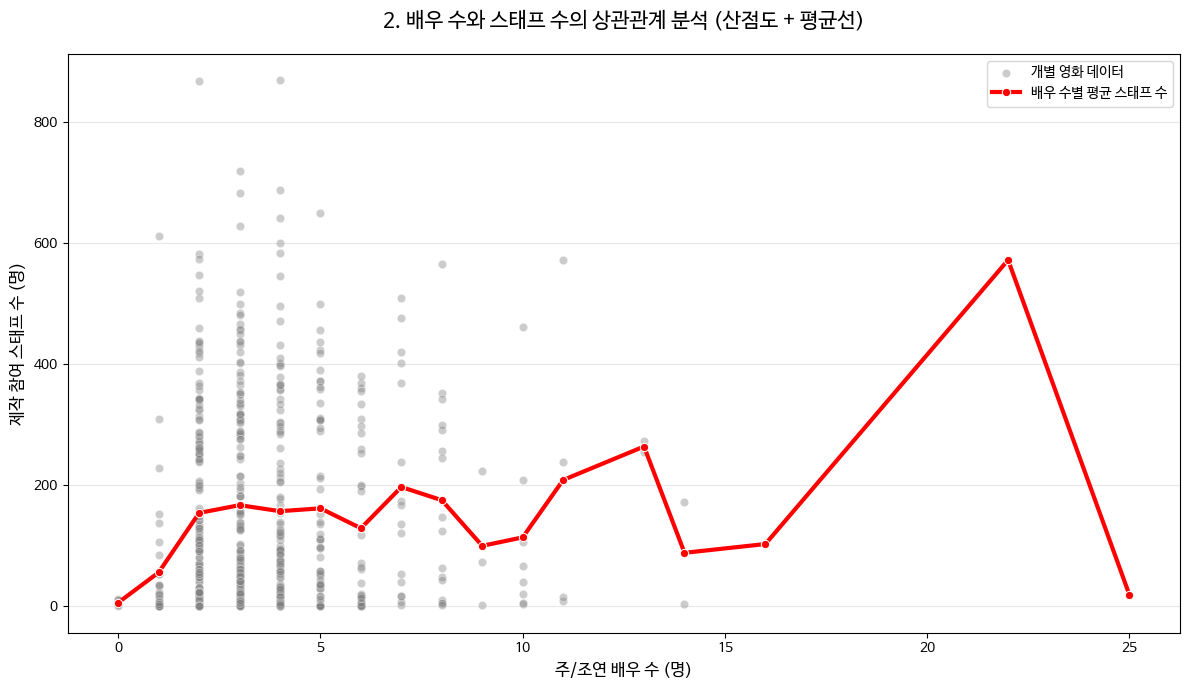

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=train, x='num_actor', y='num_staff', color='grey', alpha=0.4, label='개별 영화 데이터')
actor_staff_mean = train.groupby('num_actor')['num_staff'].mean()  # 배우 수별 평균 스태프 수를 계산하기 위해 actor_staff_mean을 정의했다

sns.lineplot(x=actor_staff_mean.index, y=actor_staff_mean.values, color='red', linewidth=3, marker='o', label='배우 수별 평균 스태프 수')
# lineplot을 통해 배우 수 변화에 따른 스태프 수의 평균 추세를 표현하고자 lineplot을 추가했다
plt.title("2. 배우 수와 스태프 수의 상관관계 분석 (산점도 + 평균선)", fontsize=15, pad=20)
plt.xlabel("주/조연 배우 수 (명)", fontsize=12)
plt.ylabel("제작 참여 스태프 수 (명)", fontsize=12)

plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5-3 가장 흥행한 영화 장르

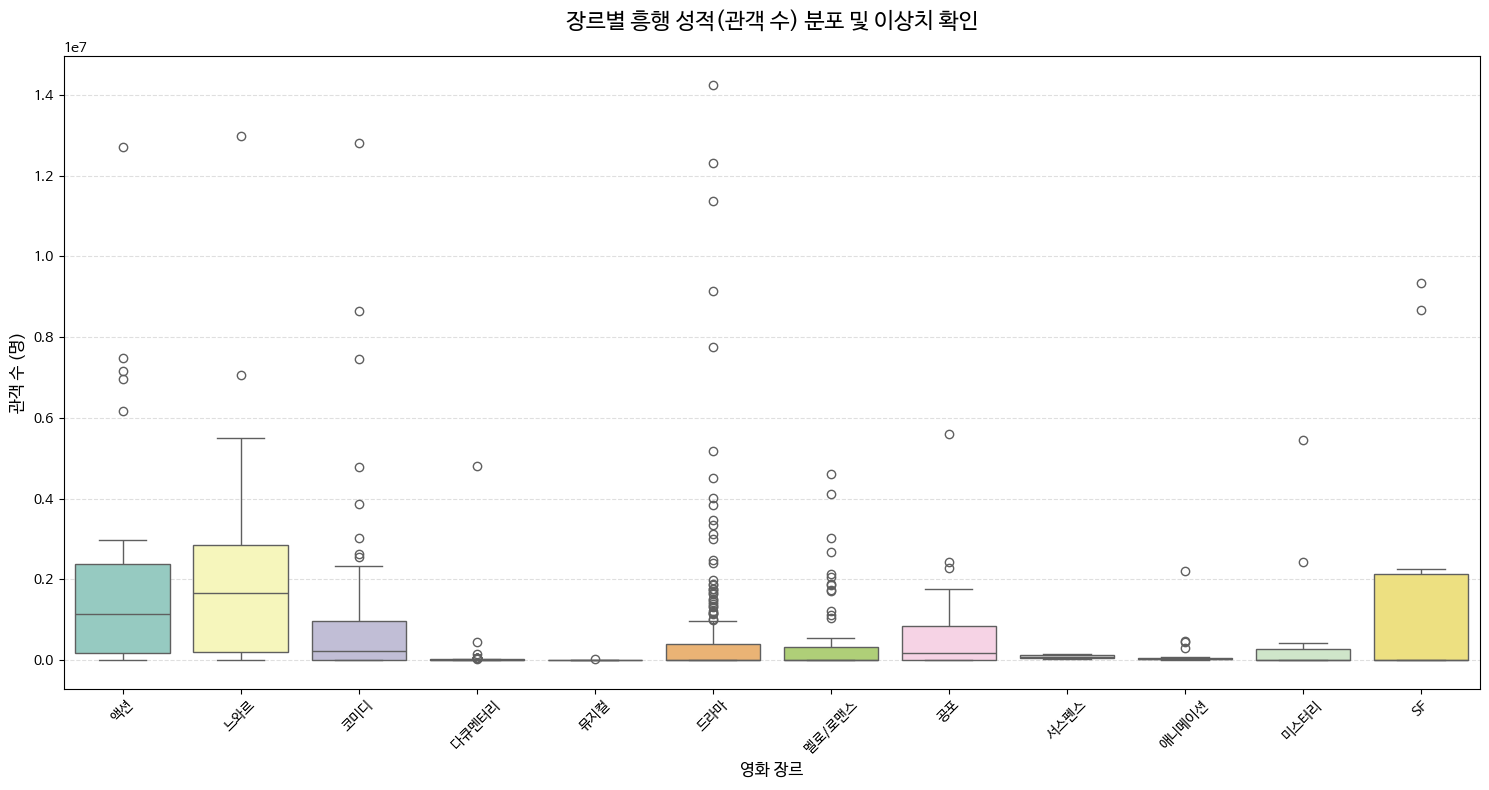

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=train, x='genre', y='box_off_num', palette='Set3')  # 장르별 관객 수의 분포를 박스 플롯으로 시각화하려고 한다
plt.title("장르별 흥행 성적(관객 수) 분포 및 이상치 확인", fontsize=16, pad=20)
plt.xlabel("영화 장르", fontsize=12)
plt.ylabel("관객 수 (명)", fontsize=12)

plt.xticks(rotation=45)  # x축 글씨가 겹치지 않게 회전
plt.grid(axis='y', linestyle='--', alpha=0.4)    # 가독성을 위한 그리드를 추가

plt.tight_layout()
plt.show()

## 5-4 제작 규모와 장르의 흥행 보장 여부(투자 대비 효율 분석)

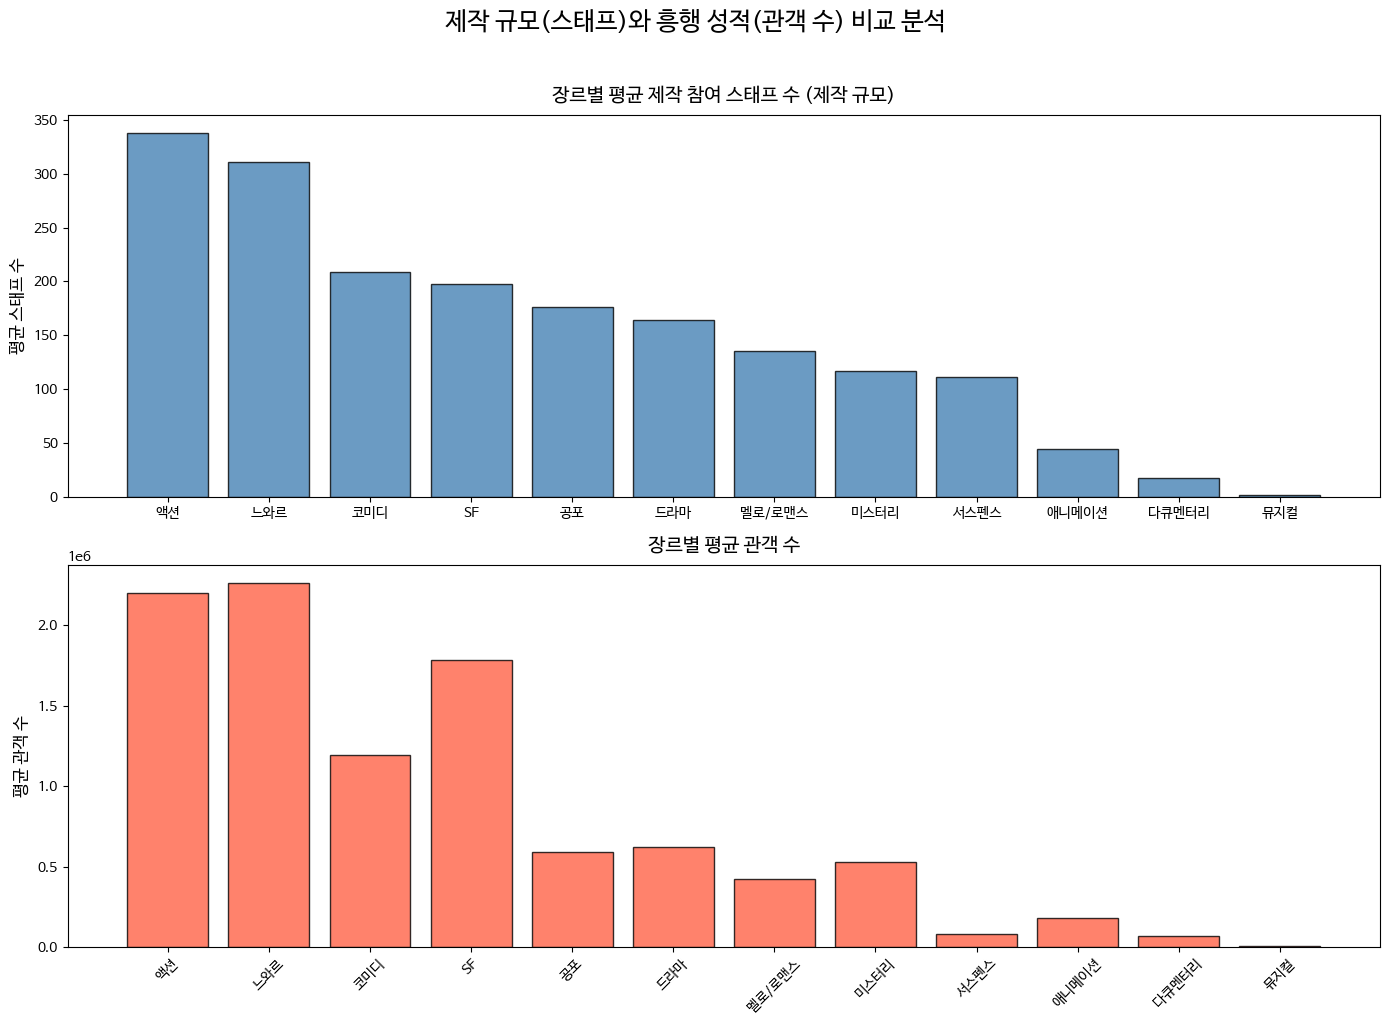

In [ ]:
genre_stats = train.groupby('genre')[['num_staff', 'box_off_num']].mean()  ## 장르별 평균 스태프 수와 평균 관객 수를 계산하기 위해 genre_stats를 정의한다
genre_stats = genre_stats.sort_values(by='num_staff', ascending=False)  ## 스태프 수(제작 규모)를 기준으로 내림차순으로 정렬한다

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))  ## nrows=2

## 두 개의 그래프를 그린다. 첫 번째 그래프는 장르별 평균 스태프 수 (제작 규모)
ax1.bar(genre_stats.index, genre_stats['num_staff'], color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title("장르별 평균 제작 참여 스태프 수 (제작 규모)", fontsize=14, pad=10)
ax1.set_ylabel("평균 스태프 수", fontsize=12)
ax1.tick_params(axis='x', rotation=0) ## 위쪽 그래프는 x축 글씨를 똑바로 두었다

## 두 번째 그래프는 장르별 평균 관객 수 (흥행 성적)
ax2.bar(genre_stats.index, genre_stats['box_off_num'], color='tomato', edgecolor='black', alpha=0.8)
ax2.set_title("장르별 평균 관객 수", fontsize=14, pad=10)
ax2.set_ylabel("평균 관객 수", fontsize=12)
ax2.tick_params(axis='x', rotation=45) ## 아래쪽 그래프는 장르 이름이 겹치지 않게 45도를 회전시킨다

plt.suptitle("제작 규모(스태프)와 흥행 성적(관객 수) 비교 분석", fontsize=18, fontweight='bold', y=1.02)  ## 전체 레이아웃을 정리하면
fig.tight_layout()
plt.show()

# 5-5 개봉 연도별 전체 관객 수 추이

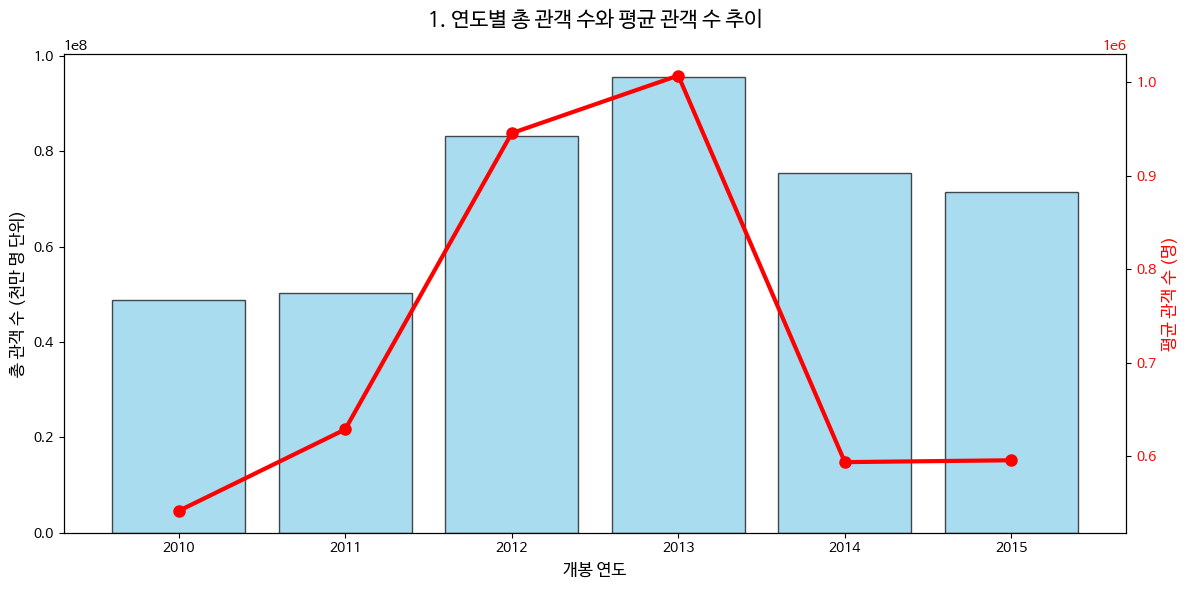

In [ ]:
#

if not pd.api.types.is_datetime64_any_dtype(train['release_time']):
    train['release_time'] = pd.to_datetime(train['release_time'])

train['release_year'] = train['release_time'].dt.year # 년도
train['month'] = train['release_time'].dt.month # 월

yearly_sum = train.groupby("release_year")["box_off_num"].sum()
yearly_mean = train.groupby("release_year")["box_off_num"].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 총 관객 수 barplot
ax1.bar(yearly_sum.index, yearly_sum.values, color='skyblue', edgecolor='black', alpha=0.7, label='총 관객 수')
ax1.set_xlabel("개봉 연도", fontsize=12)
ax1.set_ylabel("총 관객 수 (천만 명 단위)", fontsize=12)
ax1.tick_params(axis='y')

# 평균 관객 수 lineplot
ax2 = ax1.twinx()
ax2.plot(yearly_mean.index, yearly_mean.values, color='red', marker='o', linewidth=3, markersize=8, label='평균 관객 수')
ax2.set_ylabel("평균 관객 수 (명)", fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("1. 연도별 총 관객 수와 평균 관객 수 추이", fontsize=15, pad=20)
plt.xticks(yearly_sum.index)
fig.tight_layout()
plt.show()

barplot: 2013,2012,2014년도 순으로 총 관객 수가 가장 많았다.

lineplot: 2013,2012,2011년도 순으로 관객 수의 평균이 가장 높았다.

-> 2012년도와 2013년에 개봉 영화 수와 관객 수가 많았음을 알 수 있고 2014년도와 2015년도에 비교적 흥행이 낮았음을 알 수 있다.

## 5-6 장르별 개봉 연도에 따른 관객 수

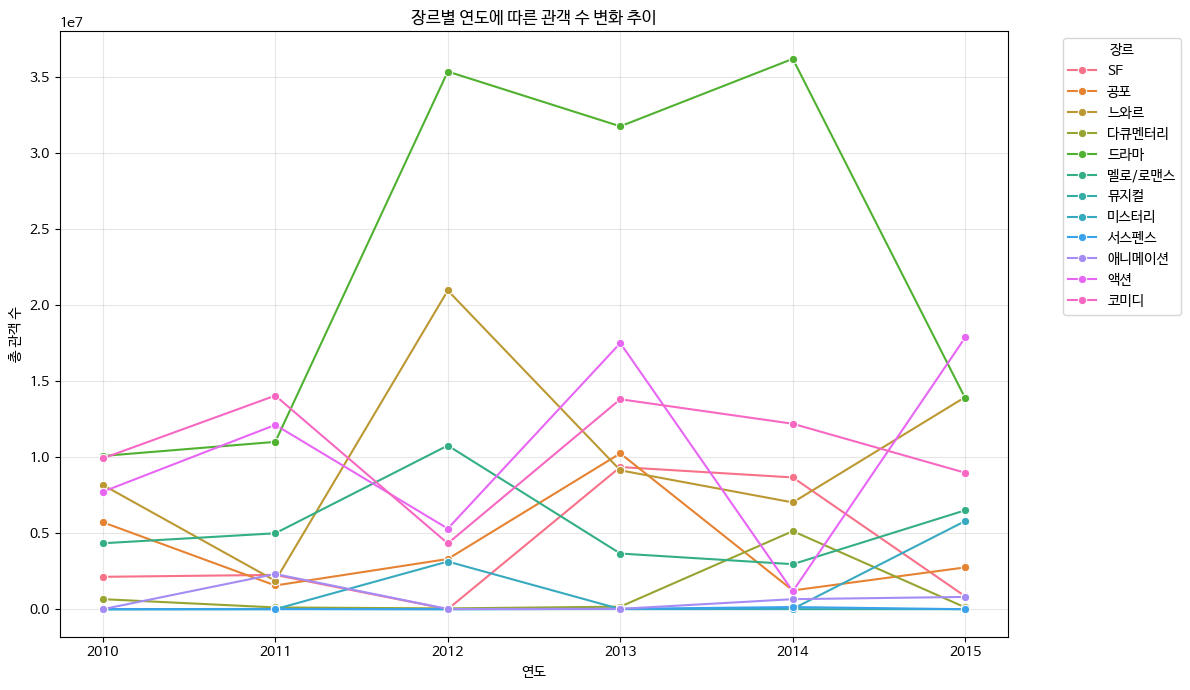

In [ ]:
genre_year = train.pivot_table(index='release_year', columns='genre', values='box_off_num', aggfunc='sum').fillna(0)

plt.figure(figsize=(12, 7))
sns.lineplot(data=genre_year, dashes=False, marker='o')

plt.title('장르별 연도에 따른 관객 수 변화 추이')
plt.xlabel('연도')
plt.ylabel('총 관객 수')
plt.legend(title='장르', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lineplot을 분석해보면 다큐멘터리와 드라마 장르의 평곤 관객 수가 안정적임을 알 수 있다.

2012년에는 느와르 장르가 폭발적인 관객 수를 기록하며 이는 한국 영화 시장에서 관객들이 시대적 분위기나 특정 트렌드에 따라 선호 장르가 변화했음을 보여준다.



## 5-7 개봉 시기(월별)와 장르별 흥행

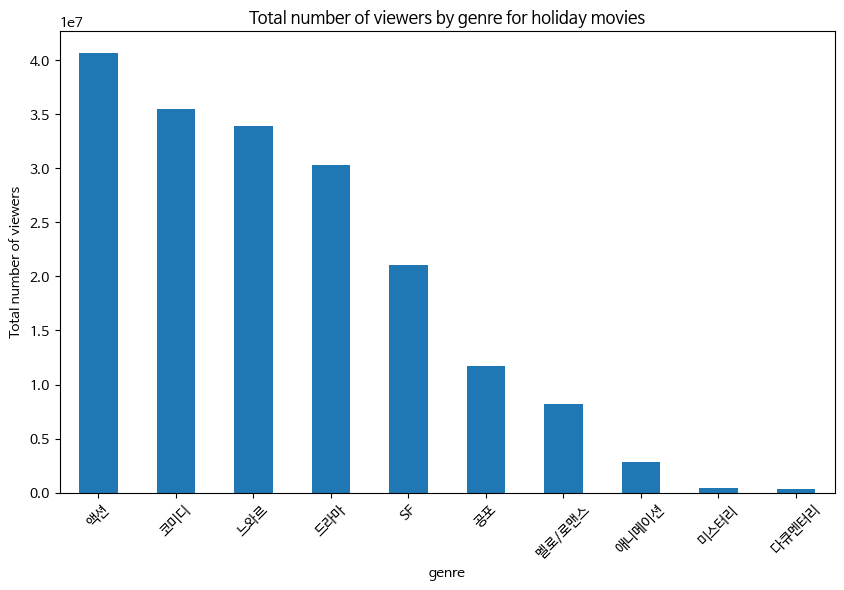

In [ ]:
df = train.copy()
df_holiday = df[df['release_time'].dt.month.isin([1,2,7,8])]

# 장르별 총 관객 수 집계
genre_counts = df_holiday.groupby('genre')['box_off_num'].sum().sort_values(ascending=False)

# 히스토그램(막대 그래프)
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')
plt.title("Total number of viewers by genre for holiday movies")
plt.xlabel("genre")
plt.ylabel("Total number of viewers")
plt.xticks(rotation=45)
plt.show()

가족 단위의 관객이나 학생층이 극장을 많이 찾는 방학 시즌을 분석해보니 액션과 코미디 장르가 최상위권을 차지하여 가볍게 즐길 수 있는 오락 영화의 선호도가 높음을 알 수 있다.

드라마 장르는 방학 시즌에도 상위권임을 알 수 있는데 이는 특정 연령대에 국한되지 않고 전 세대를 아우른다는 것을 보여준다.

## 5-8 감독의 유명세와 흥행의 상관관계

원자료 상관계수: 0.28318418963286685
로그변환 상관계수: 0.40888182432233966


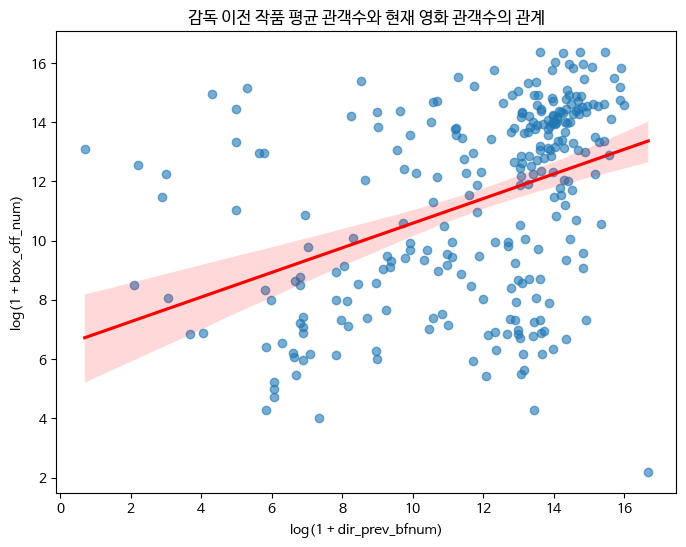

In [ ]:
from IPython.core.display import set_matplotlib_close
df = train[['director', 'dir_prev_bfnum', 'box_off_num']].dropna().copy()

df['log_dir_prev_bfnum'] = np.log1p(df['dir_prev_bfnum'])
df['log_box_off_num'] = np.log1p(df['box_off_num'])

print("원자료 상관계수:", df['dir_prev_bfnum'].corr(df['box_off_num']))
print("로그변환 상관계수:", df['log_dir_prev_bfnum'].corr(df['log_box_off_num']))

plt.figure(figsize=(8,6))
sns.regplot(data=df, x='log_dir_prev_bfnum', y='log_box_off_num',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('감독 이전 작품 평균 관객수와 현재 영화 관객수의 관계')
plt.xlabel('log(1 + dir_prev_bfnum)')
plt.ylabel('log(1 + box_off_num)')
plt.show()

감독의 이전 작품 평균 관객수와 현재 영화 관객수 사이에는 양의 상관관계가 나타났다. 특히 로그 변환 후 상관계수는 0.409로, 이전 작품이 흥행한 감독일수록 현재 작품도 흥행하는 경향이 어느 정도 확인되었다. 또한, 그래프가 우상향인 것을 통해서도 확인가능하다. 따라서 이전 작품의 흥행으로 인한 감독의 유명세는 후속 작품의 흥행과 관련이 있다고 볼 수 있다. 다만 그 관계가 아주 강한 수준은 아니므로, 흥행은 다른 요인들과 함께 해석할 필요가 있다.

##5-9 대기업/중소기업 배급사의 관객수 비교

In [ ]:
train['distributor'].value_counts().head(10)

,count
distributor,
CJ 엔터테인먼트,54
롯데엔터테인먼트,52
(주)NEW,30
(주)마운틴픽쳐스,29
(주)쇼박스,26
인디스토리,26
골든타이드픽처스,15
(주) 케이알씨지,14
시너지,10


배급사 규모를 직접 나타내는 변수가 없으므로, 본 분석에서는 데이터 내 배급 편수와 영화시장 내 인지도를 함께 고려하여 CJ 엔터테인먼트, 롯데엔터테인먼트, NEW, 쇼박스, 인디스토리를 주요 배급사로 분류하고, 그 외 배급사는 중소 배급사로 구분하였다.

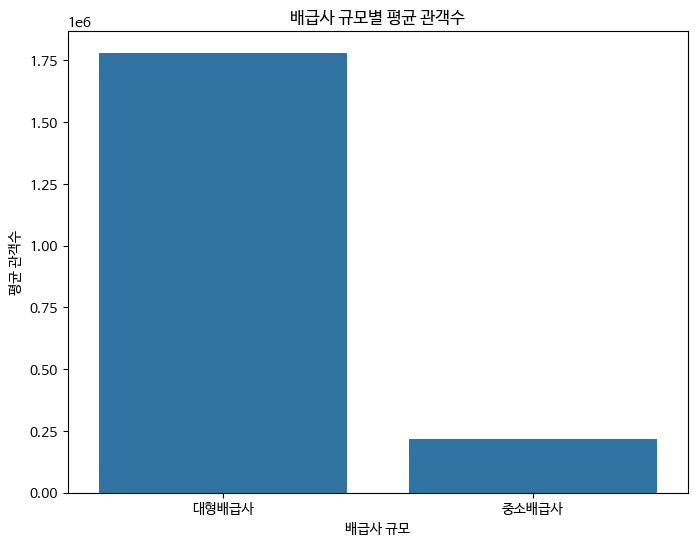

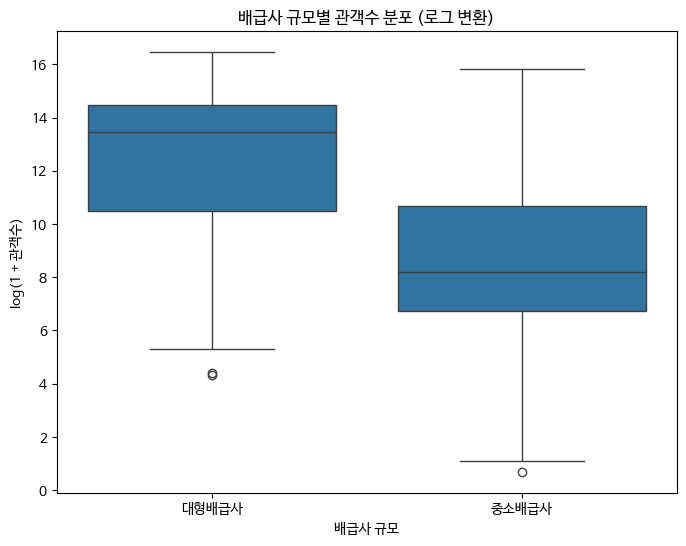


배급사 규모별 영화 수
dist_group
중소배급사    412
대형배급사    188
Name: count, dtype: int64


In [ ]:
df_dist = train[['distributor', 'box_off_num']].dropna().copy()

def classify_distributor(x):
    x = str(x).strip()

    big_companies = [
        'CJ 엔터테인먼트',
        '롯데엔터테인먼트',
        '(주)NEW',
        '(주)쇼박스',
        '인디스토리'
    ]

    if x in big_companies:
        return '대형배급사'
    else:
        return '중소배급사'

df_dist['dist_group'] = df_dist['distributor'].apply(classify_distributor)

group_mean = df_dist.groupby('dist_group', as_index=False)['box_off_num'].mean()

plt.figure(figsize=(8,6))
sns.barplot(data=group_mean, x='dist_group', y='box_off_num')
plt.title('배급사 규모별 평균 관객수')
plt.xlabel('배급사 규모')
plt.ylabel('평균 관객수')
plt.show()

df_dist['log_box_off_num'] = np.log1p(df_dist['box_off_num'])

plt.figure(figsize=(8,6))
sns.boxplot(data=df_dist, x='dist_group', y='log_box_off_num')
plt.title('배급사 규모별 관객수 분포 (로그 변환)')
plt.xlabel('배급사 규모')
plt.ylabel('log(1 + 관객수)')
plt.show()

print("\n배급사 규모별 영화 수")
print(df_dist['dist_group'].value_counts())

배급사를 대형배급사와 중소배급사로 구분하여 비교한 결과, 대형배급사가 배급한 영화의 평균 관객 수가 더 높게 나타났다. 박스플롯에서도 대형배급사 집단의 중앙값과 전반적인 관객 수 수준이 더 높아, 배급사의 규모와 영화 흥행 사이에 일정한 관련성이 있음을 확인할 수 있었다. 따라서 대형배급사가 배급한 영화일수록 더 많은 관객을 동원하는 경향이 있다고 볼 수 있다.

##5-10 감독 이전 참여 영화 편수와 현재 영화 관객수의 관계

상관계수: 0.25967385777851376


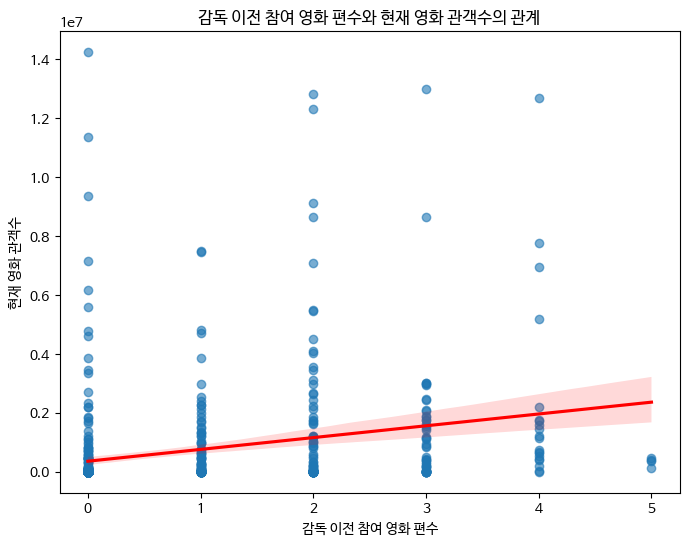

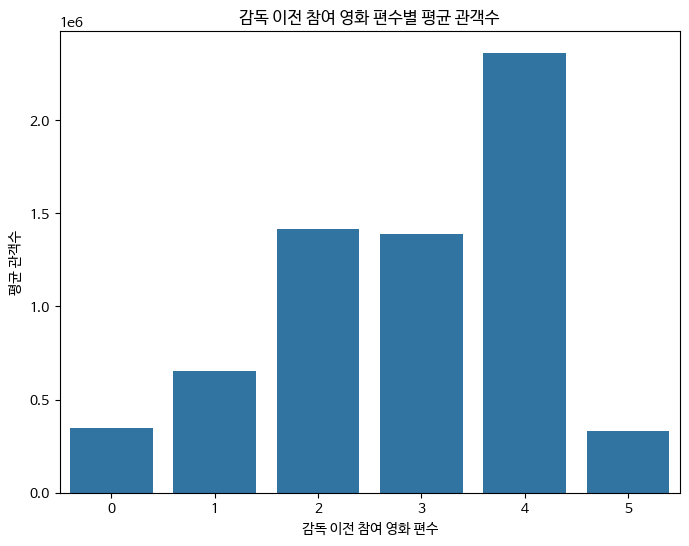

In [ ]:
df_dir = train[['dir_prev_num', 'box_off_num']].dropna().copy()

print("상관계수:", df_dir['dir_prev_num'].corr(df_dir['box_off_num']))

plt.figure(figsize=(8,6))
sns.regplot(
    data=df_dir,
    x='dir_prev_num',
    y='box_off_num',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('감독 이전 참여 영화 편수와 현재 영화 관객수의 관계')
plt.xlabel('감독 이전 참여 영화 편수')
plt.ylabel('현재 영화 관객수')
plt.show()

mean_by_count = df_dir.groupby('dir_prev_num', as_index=False)['box_off_num'].mean()

plt.figure(figsize=(8,6))
sns.barplot(data=mean_by_count, x='dir_prev_num', y='box_off_num')
plt.title('감독 이전 참여 영화 편수별 평균 관객수')
plt.xlabel('감독 이전 참여 영화 편수')
plt.ylabel('평균 관객수')
plt.show()

감독의 이전 참여 영화 편수와 현재 영화 관객수 사이에는 약한 양의 상관관계가 나타났다. 상관계수는 약 0.260이었으며, 산점도의 회귀선 역시 우상향하여 감독의 이전 참여 편수가 많을수록 현재 영화의 관객수가 증가하는 경향이 있음을 보여주었다. 편수별 평균 관객수 또한 전반적으로 증가하는 모습을 보여, 감독의 경험은 영화 흥행과 어느 정도 관련이 있다고 볼 수 있다. 다만 그 관계가 아주 강한 수준은 아니므로, 흥행은 다른 요인들과 함께 해석할 필요가 있다.